In [9]:
from pipeline.run_roma import intersect_samples, test_stage_association
import pandas as pd
from romapy import ROMA, load_gmt

In [10]:
clinical_clean = pd.read_csv("./data/processed/cleaned_clinical.csv")
mrna_clean = pd.read_csv("./data/processed/cleaned_mrna.csv")
gene_sets = load_gmt("./data/raw/h.all.v2026.1.Hs.symbols.gmt")

clinical_clean = clinical_clean.set_index("Sample ID")
mrna_clean = mrna_clean.set_index("Hugo_Symbol")

clinical_clean, mrna_clean = intersect_samples(clinical_clean, mrna_clean)

[run_roma] dropping 4 clinical-only and 2 expression-only samples; 508 samples in common


In [11]:
roma = ROMA(center="fixed", robust=True, n_permutations=200, random_state=0)
results = roma.fit(mrna_clean, gene_sets)
sig = results.significant(alpha=0.05)
sig

,l1,l1_pval,coord
HALLMARK_ALLOGRAFT_REJECTION,0.285422,0.000,0.000
HALLMARK_ANGIOGENESIS,0.382345,0.000,0.000
HALLMARK_COMPLEMENT,0.151580,0.000,0.000
HALLMARK_E2F_TARGETS,0.489344,0.000,0.000
HALLMARK_G2M_CHECKPOINT,0.409110,0.000,0.000
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,0.288645,0.000,0.000
HALLMARK_INFLAMMATORY_RESPONSE,0.205679,0.000,0.000
HALLMARK_IL6_JAK_STAT3_SIGNALING,0.231582,0.000,0.000
HALLMARK_MITOTIC_SPINDLE,0.178540,0.000,0.000
HALLMARK_KRAS_SIGNALING_UP,0.150740,0.000,0.000


In [12]:
stage_assoc = test_stage_association(results, clinical_clean)
stage_assoc.head(10)

,f_stat,stage_anova_pval,stage_anova_pval_adj
module,,,
HALLMARK_MYC_TARGETS_V1,6.551373,2.099864e-07,0.000005
HALLMARK_MTORC1_SIGNALING,5.605872,3.110758e-06,0.000039
HALLMARK_UV_RESPONSE_UP,4.880439,2.430352e-05,0.000203
HALLMARK_UNFOLDED_PROTEIN_RESPONSE,4.470228,7.734338e-05,0.000483
HALLMARK_SPERMATOGENESIS,4.142983,1.927655e-04,0.000752
HALLMARK_G2M_CHECKPOINT,4.137505,1.953911e-04,0.000752
HALLMARK_E2F_TARGETS,4.110084,2.104995e-04,0.000752
HALLMARK_MITOTIC_SPINDLE,3.740361,5.840619e-04,0.001825
HALLMARK_MYC_TARGETS_V2,3.075041,3.526506e-03,0.009796


<Axes: title={'center': 'score'}, xlabel='stage'>

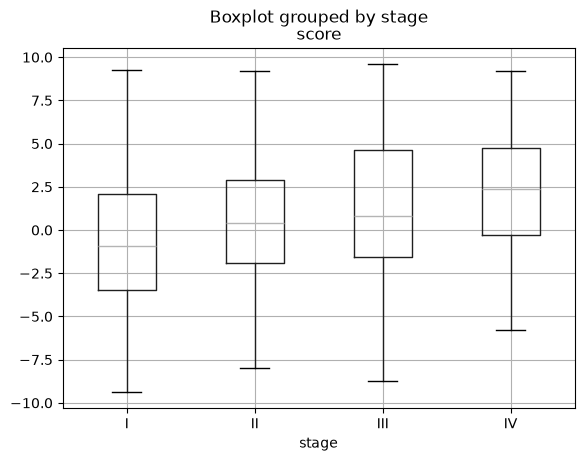

In [13]:
top_module = stage_assoc.index[0]
clinical_clean["C_STAGE_BROAD"] = clinical_clean["C_STAGE"].str.extract(r"(IV|III|II|I)")[0]
merged = pd.DataFrame({"score": results.scores.loc[top_module], "stage": clinical_clean["C_STAGE_BROAD"]})
merged.boxplot(column="score", by="stage")